In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.plots import save_chart
from category_encoders import TargetEncoder

vs = {"width": 1200, "height": 700, "scale": 3, "renderer": "png"}
vs_box = {"width": 1200, "height": 1200, "scale": 3, "renderer": "png"}

2025-01-13 23:47:23.354 | INFO     | src.config:<module>:12 - PROJ_ROOT path is: /Users/victor.barbarich/PycharmProjects/personal-projects/automl-itmo-insurance


In [2]:
data = pd.read_feather(PROCESSED_DATA_DIR / 'train.feather')

# Типизация признаков (числовые, категориальные, временные) и их распределения


Датасет содержит числовые, категориальные и временные признаки:

- **Числовые:** возраст, доход, количество иждивенцев, баллы здоровья, предыдущие обращения, возраст автомобиля, кредитный рейтинг, срок страхования, сумма премии.
- **Категориальные:** пол, семейное положение, уровень образования, профессия, местоположение, тип полиса, обратная связь клиента, статус курения, частота упражнений, тип собственности.
- **Временные:** дата начала полиса.



In [3]:
pd.DataFrame({
    "n_unique": data.nunique(),
    "dtype": data.dtypes
})

,n_unique,dtype
ID,1200000,int64
AGE,47,float64
GENDER,2,object
ANNUAL_INCOME,88593,float64
MARITAL_STATUS,3,object
NUMBER_OF_DEPENDENTS,5,float64
EDUCATION_LEVEL,4,object
OCCUPATION,3,object
HEALTH_SCORE,532655,float64
LOCATION,3,object


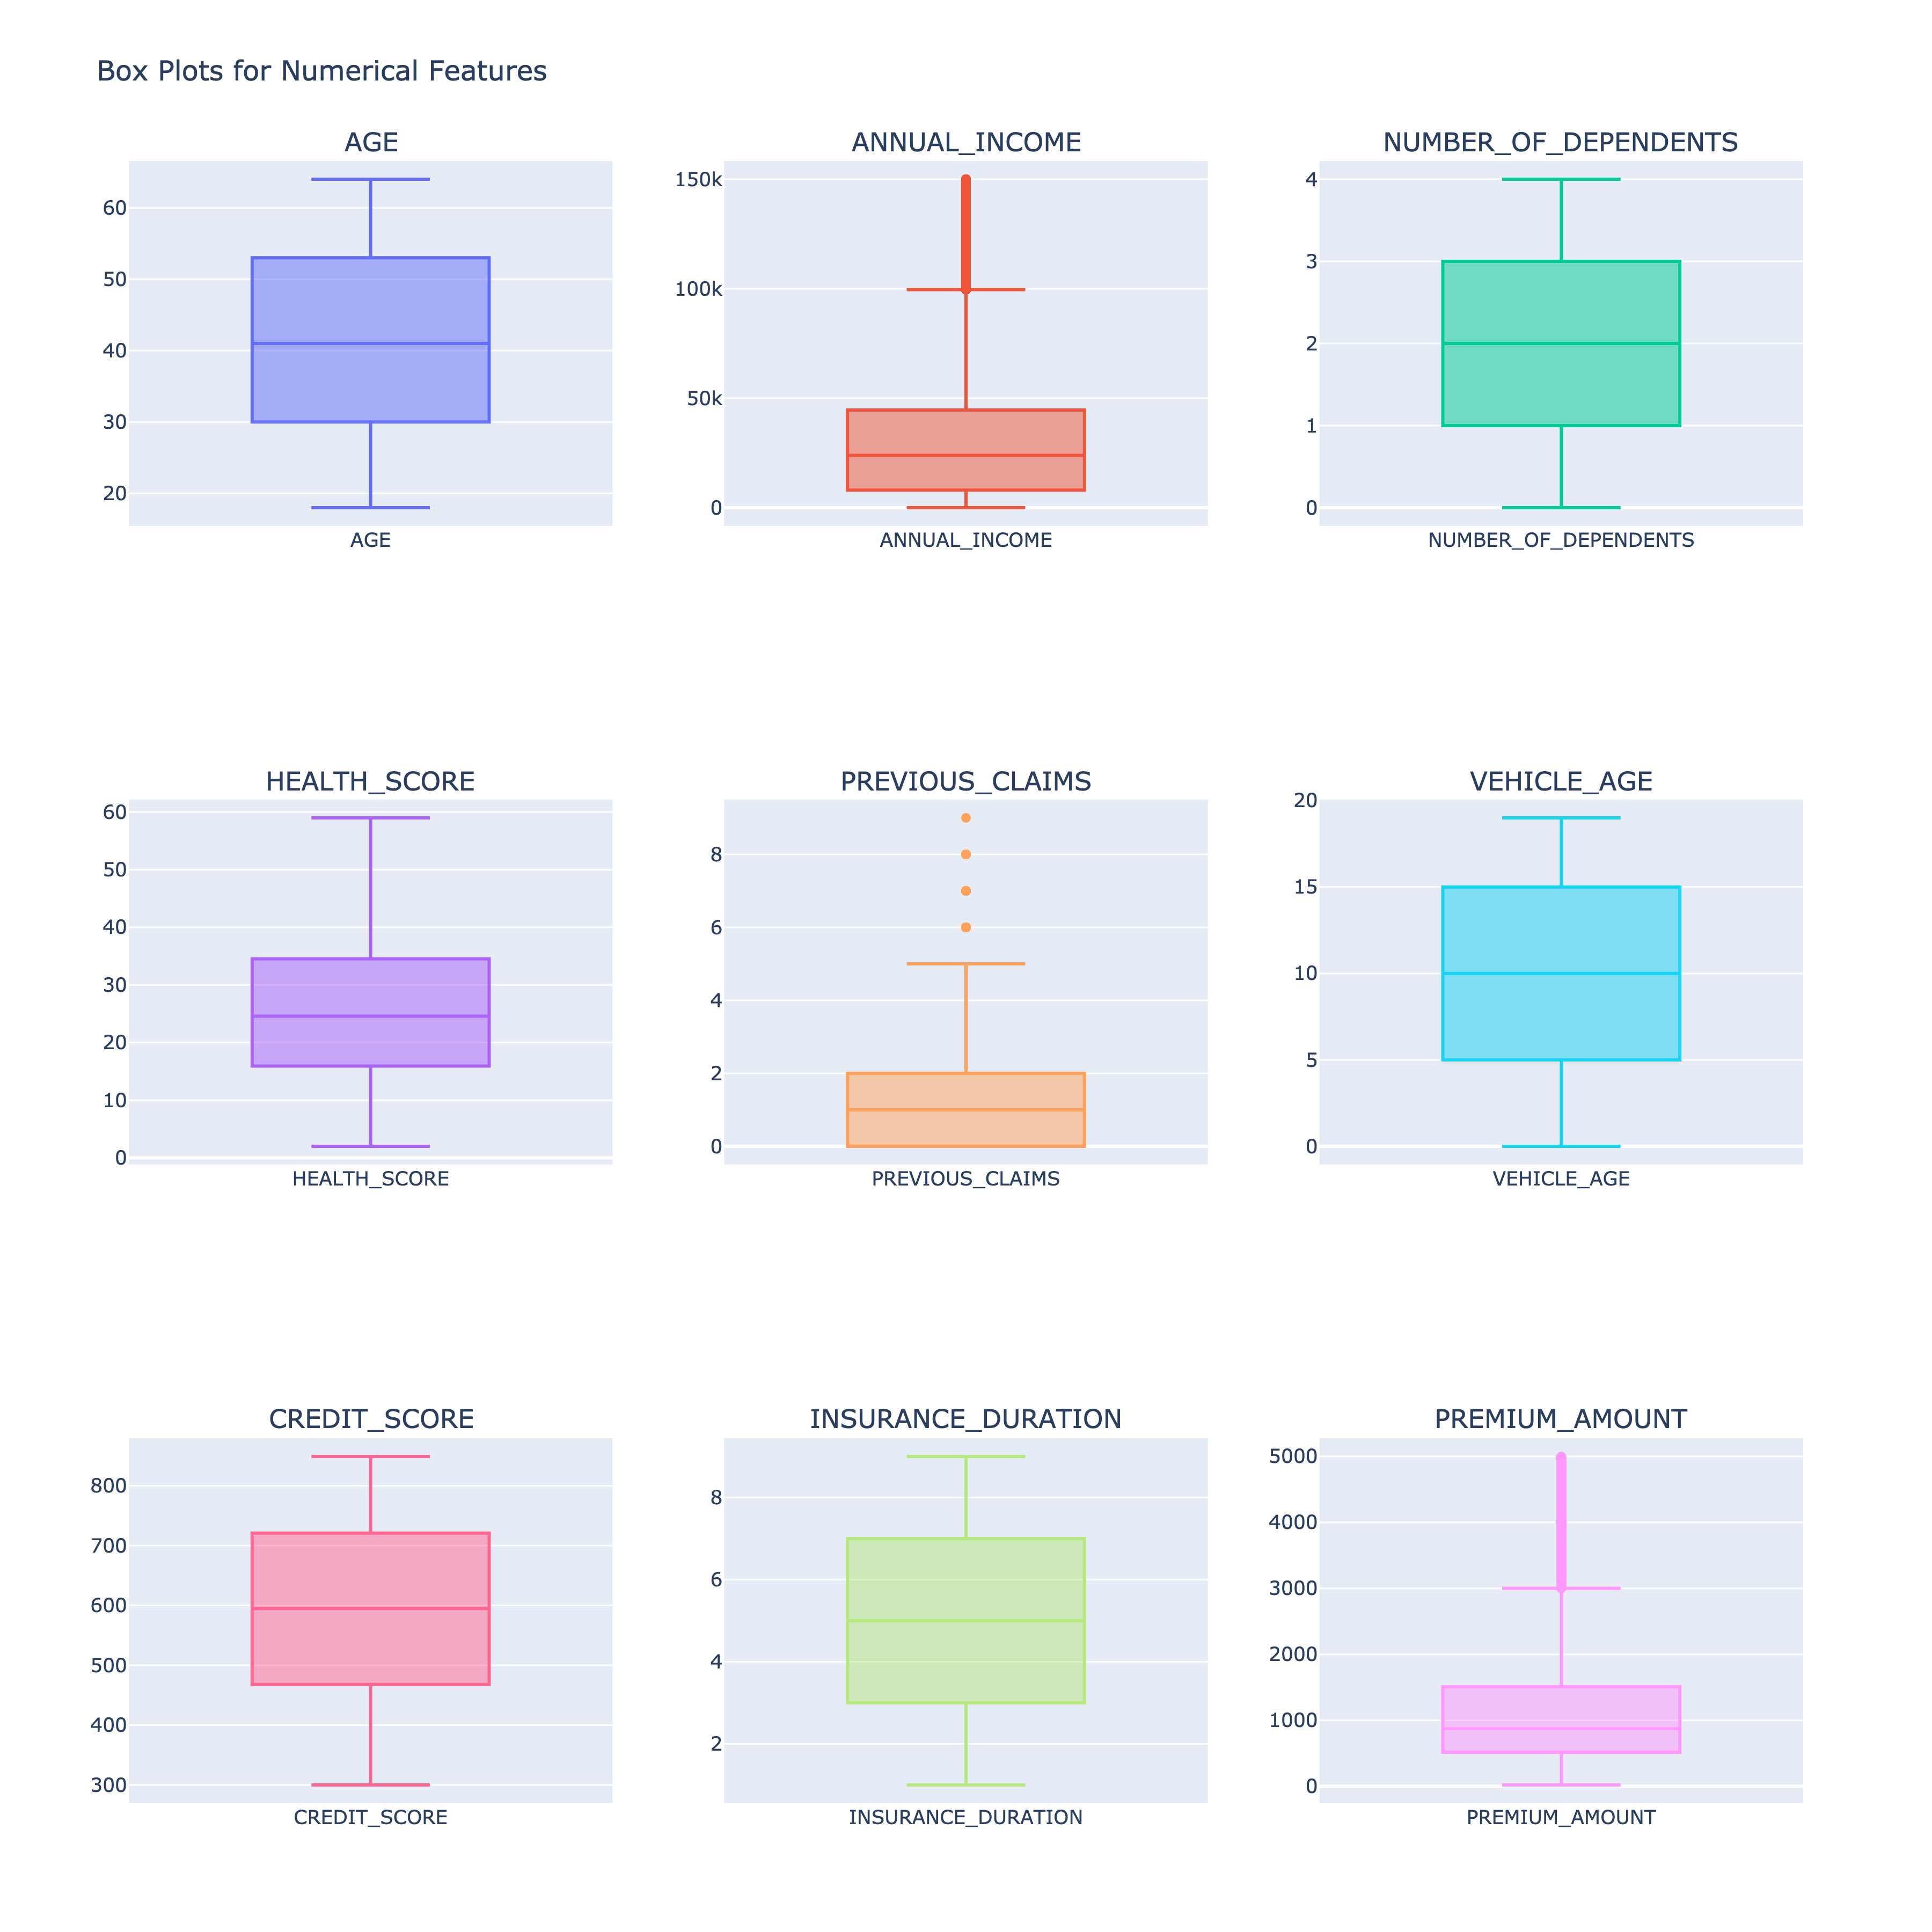

In [4]:
def plot_boxplots_grid(data_: pd.DataFrame):
    """
    Plot box plots for numerical features in a grid
    """

    # Identify numerical columns
    numerical_columns = data_.select_dtypes(include=['float64', 'int64']).columns

    # Determine grid size based on the number of features
    num_features = len(numerical_columns)
    cols = 3  # Number of columns in the grid
    rows = -(-num_features // cols)  # Calculate rows, round up

    # Create subplots
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=numerical_columns)

    # Add box plots for each numerical column
    for idx, column in enumerate(numerical_columns):
        row = (idx // cols) + 1
        col = (idx % cols) + 1
        fig.add_trace(
            go.Box(y=data_[column], name=column),
            row=row, col=col
        )

    # Update layout
    fig.update_layout(
        title="Box Plots for Numerical Features",
        height=300 * rows,  # Adjust height based on rows
        showlegend=False
    )

    return fig


fig_distribution = plot_boxplots_grid(data.drop(columns=["ID", "POLICY_START_DATE"]))
fig_distribution.show(**vs_box)

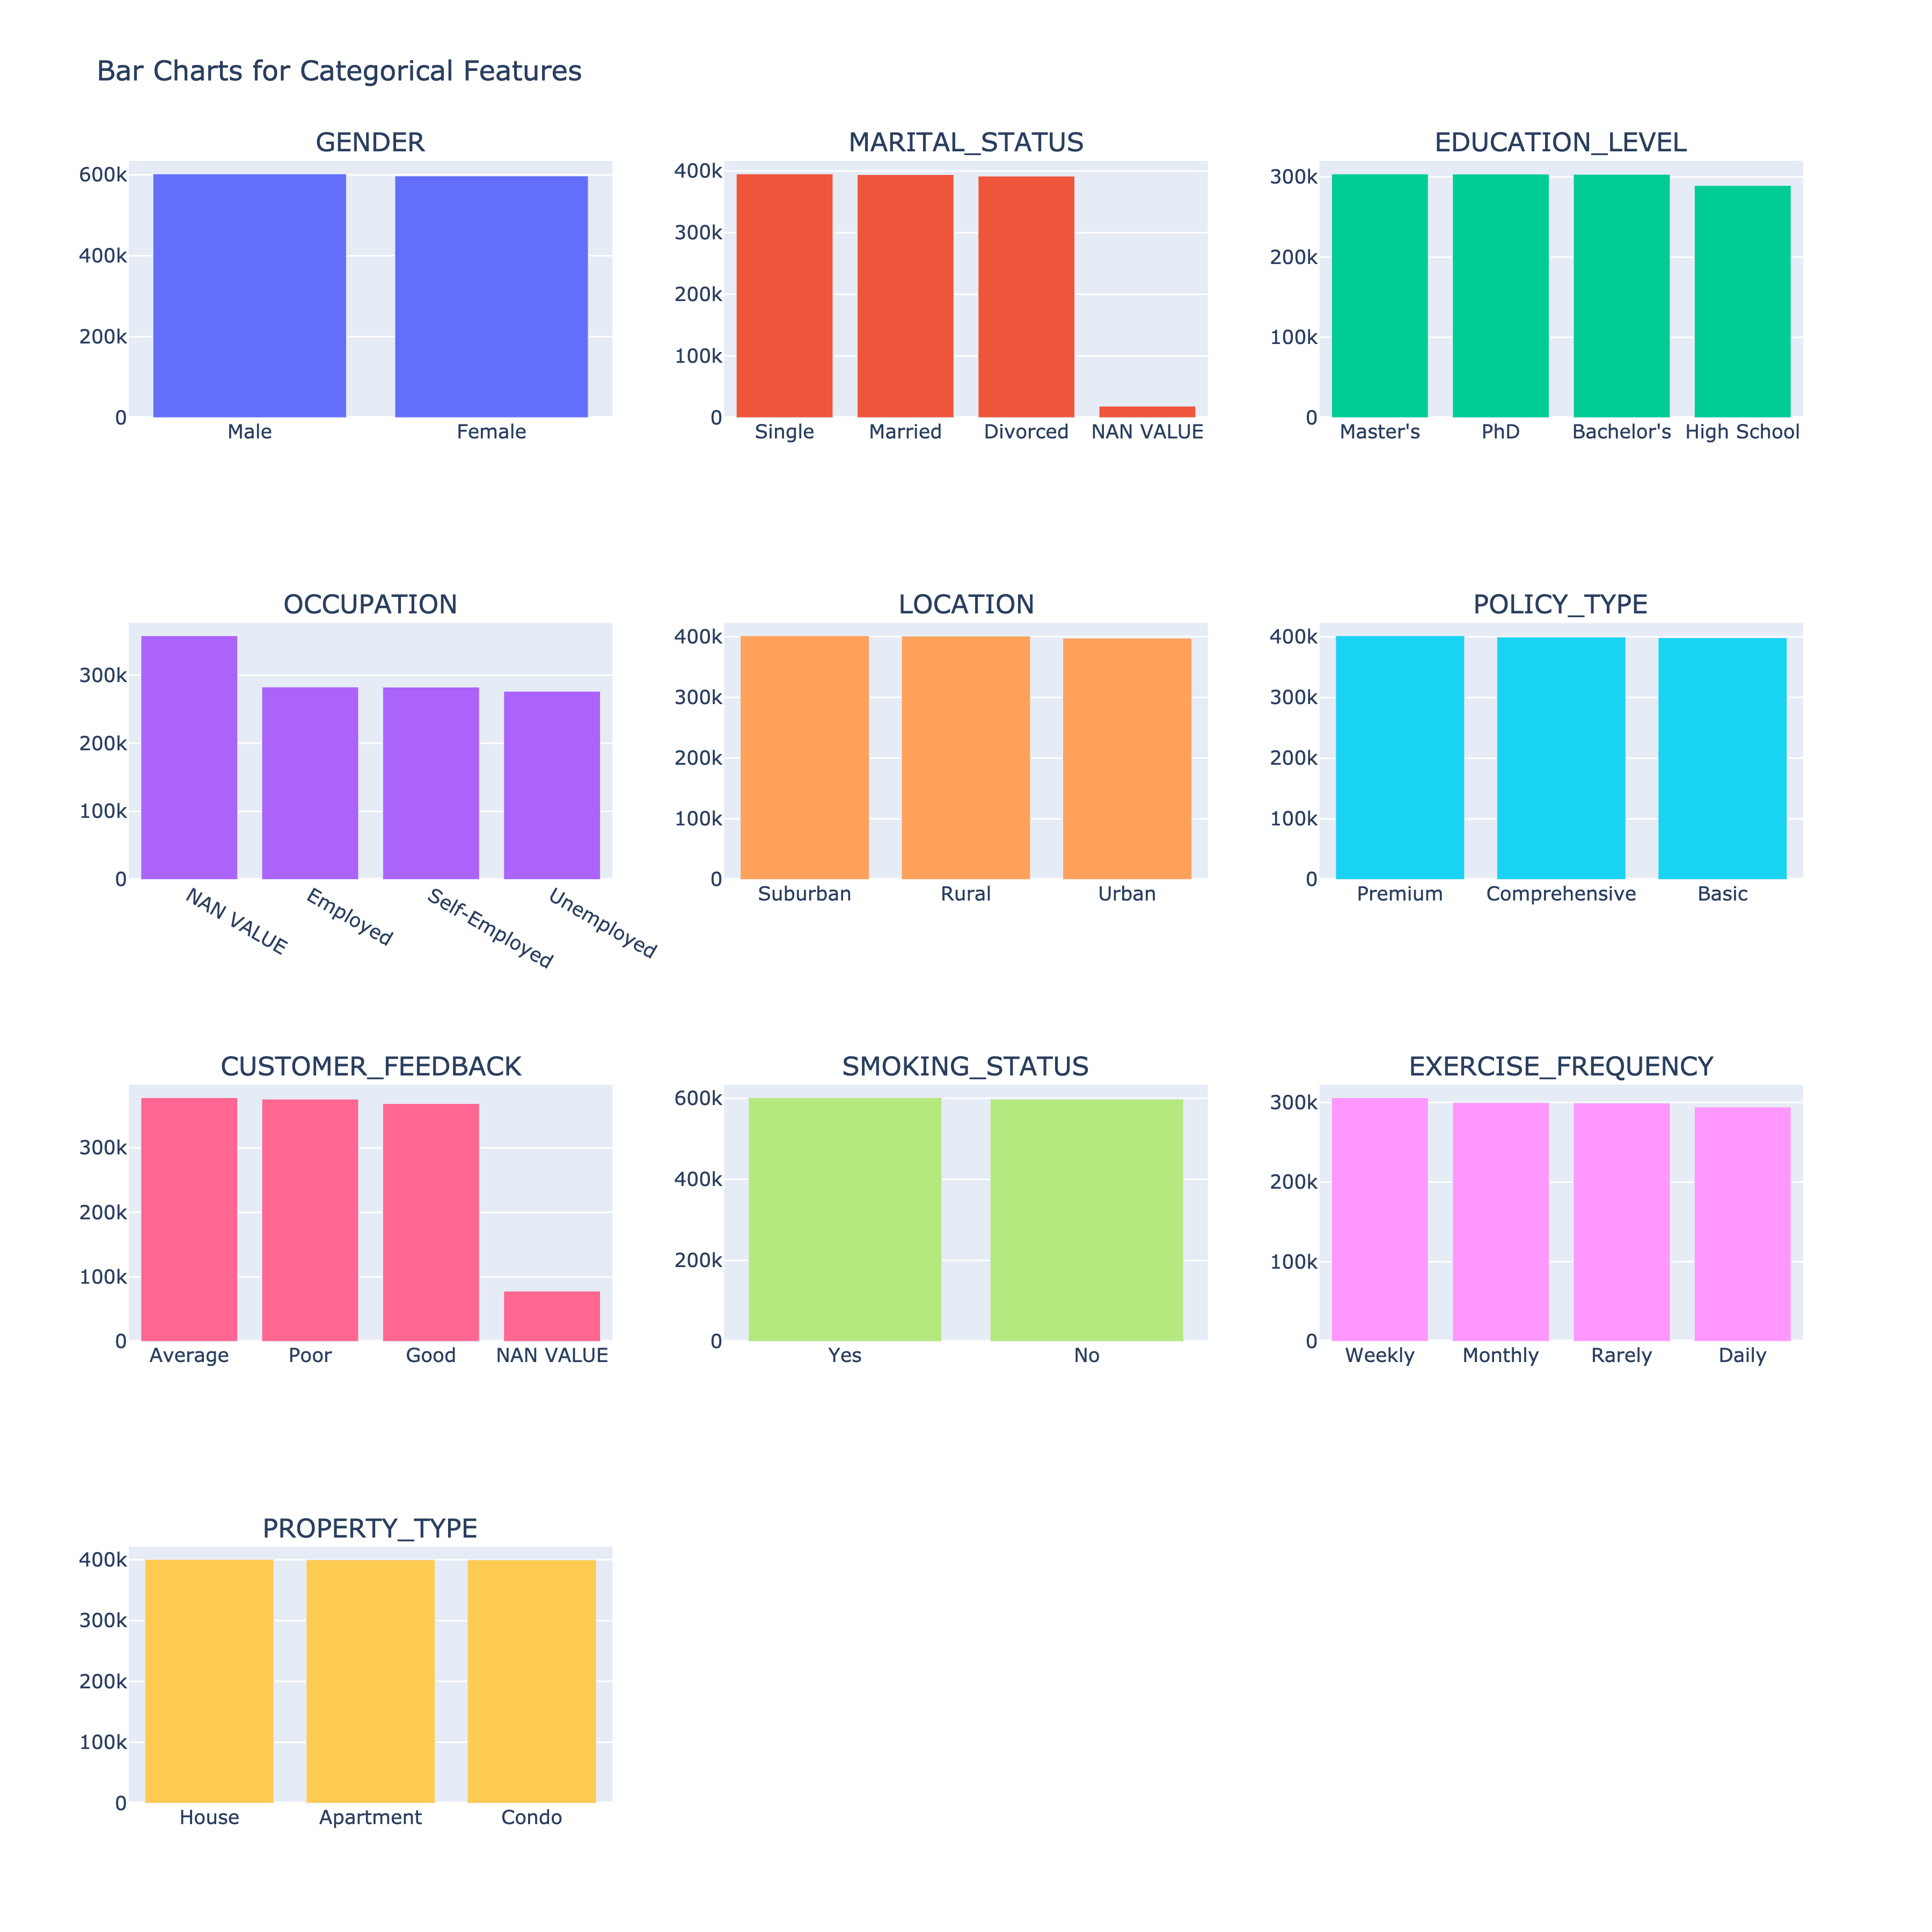

In [5]:
def plot_barcharts_grid(data_: pd.DataFrame):
    """
    Function to plot bar charts in a grid for categorical features
    """
    # Identify categorical columns
    categorical_columns = data_.select_dtypes(include=['object', 'category']).columns

    # Determine grid size based on the number of features
    num_features = len(categorical_columns)
    cols = 3  # Number of columns in the grid
    rows = -(-num_features // cols)  # Calculate rows, round up

    # Create subplots
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=categorical_columns)

    # Add bar charts for each categorical column
    for idx, column in enumerate(categorical_columns):
        row = (idx // cols) + 1
        col = (idx % cols) + 1
        value_counts = data_[column].fillna("NAN VALUE").value_counts()
        fig.add_trace(
            go.Bar(x=value_counts.index, y=value_counts.values, name=column),
            row=row, col=col
        )

    # Update layout
    fig.update_layout(
        title="Bar Charts for Categorical Features",
        height=300 * rows,  # Adjust height based on rows
        showlegend=False
    )

    return fig


fig_bars = plot_barcharts_grid(data.drop(columns=["ID", "POLICY_START_DATE"]))
fig_bars.show(**vs_box)

# Выявление аномальных значений

Данные выглядят очищенными или синтетическими:
- Категориальные данные распределены равномерно.
- Числовые данные практически не содержат выбросов, за исключением возможных выбросов в **PREVIOUS_CLAIMS**.
- Для **ANNUAL_INCOME** и **PREMIUM_AMOUNT** широкий правый хвост является нормальным, что соответствует классическому распределению таких величин.

# Анализ зависимостей между признаками

Матрица корреляции показывает, что переменные практически не связаны друг с другом. При условии, что мы использовали TargetEncoder для категориальных признаков, даже при этом методе кодирования корреляция между признаками остается низкой. Это хорошо, так как это означает, что признаки не являются линейно зависимыми и не содержат мультиколлинеарности.



In [6]:
encoder: TargetEncoder = TargetEncoder()
encoder.fit(data, data.PREMIUM_AMOUNT)
data_enc = encoder.transform(data)

data_enc["POLICY_START_DATE"] = data["POLICY_START_DATE"]
data_enc.head(5)

,ID,AGE,GENDER,ANNUAL_INCOME,MARITAL_STATUS,NUMBER_OF_DEPENDENTS,EDUCATION_LEVEL,OCCUPATION,HEALTH_SCORE,LOCATION,...,PREVIOUS_CLAIMS,VEHICLE_AGE,CREDIT_SCORE,INSURANCE_DURATION,POLICY_START_DATE,CUSTOMER_FEEDBACK,SMOKING_STATUS,EXERCISE_FREQUENCY,PROPERTY_TYPE,PREMIUM_AMOUNT
0,0,19.0,1102.404974,10049.0,1099.844389,1.0,1102.698438,1106.609284,22.598761,1103.714936,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,1098.892745,1102.403607,1101.234252,1101.561680,2869.0
1,1,39.0,1102.404974,31678.0,1100.625116,3.0,1102.113989,1093.320969,15.569731,1101.467665,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,1094.350977,1102.685158,1103.011720,1101.561680,1483.0
2,2,23.0,1102.683476,25602.0,1100.625116,3.0,1104.787490,1106.609284,47.177549,1102.462014,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,1096.284299,1102.685158,1101.234252,1101.561680,567.0
3,3,21.0,1102.683476,141855.0,1099.844389,2.0,1102.698438,1093.320969,10.938144,1101.467665,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,1098.892745,1102.685158,1103.789093,1104.150596,765.0
4,4,21.0,1102.683476,39651.0,1101.735535,1.0,1102.698438,1106.609284,20.376094,1101.467665,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,1098.892745,1102.685158,1101.234252,1101.561680,2022.0


In [7]:
pd.DataFrame({
    "n_unique": data_enc.nunique(),
    "dtype": data_enc.dtypes
})

,n_unique,dtype
ID,1200000,int64
AGE,47,float64
GENDER,2,float64
ANNUAL_INCOME,88593,float64
MARITAL_STATUS,4,float64
NUMBER_OF_DEPENDENTS,5,float64
EDUCATION_LEVEL,4,float64
OCCUPATION,4,float64
HEALTH_SCORE,532655,float64
LOCATION,3,float64


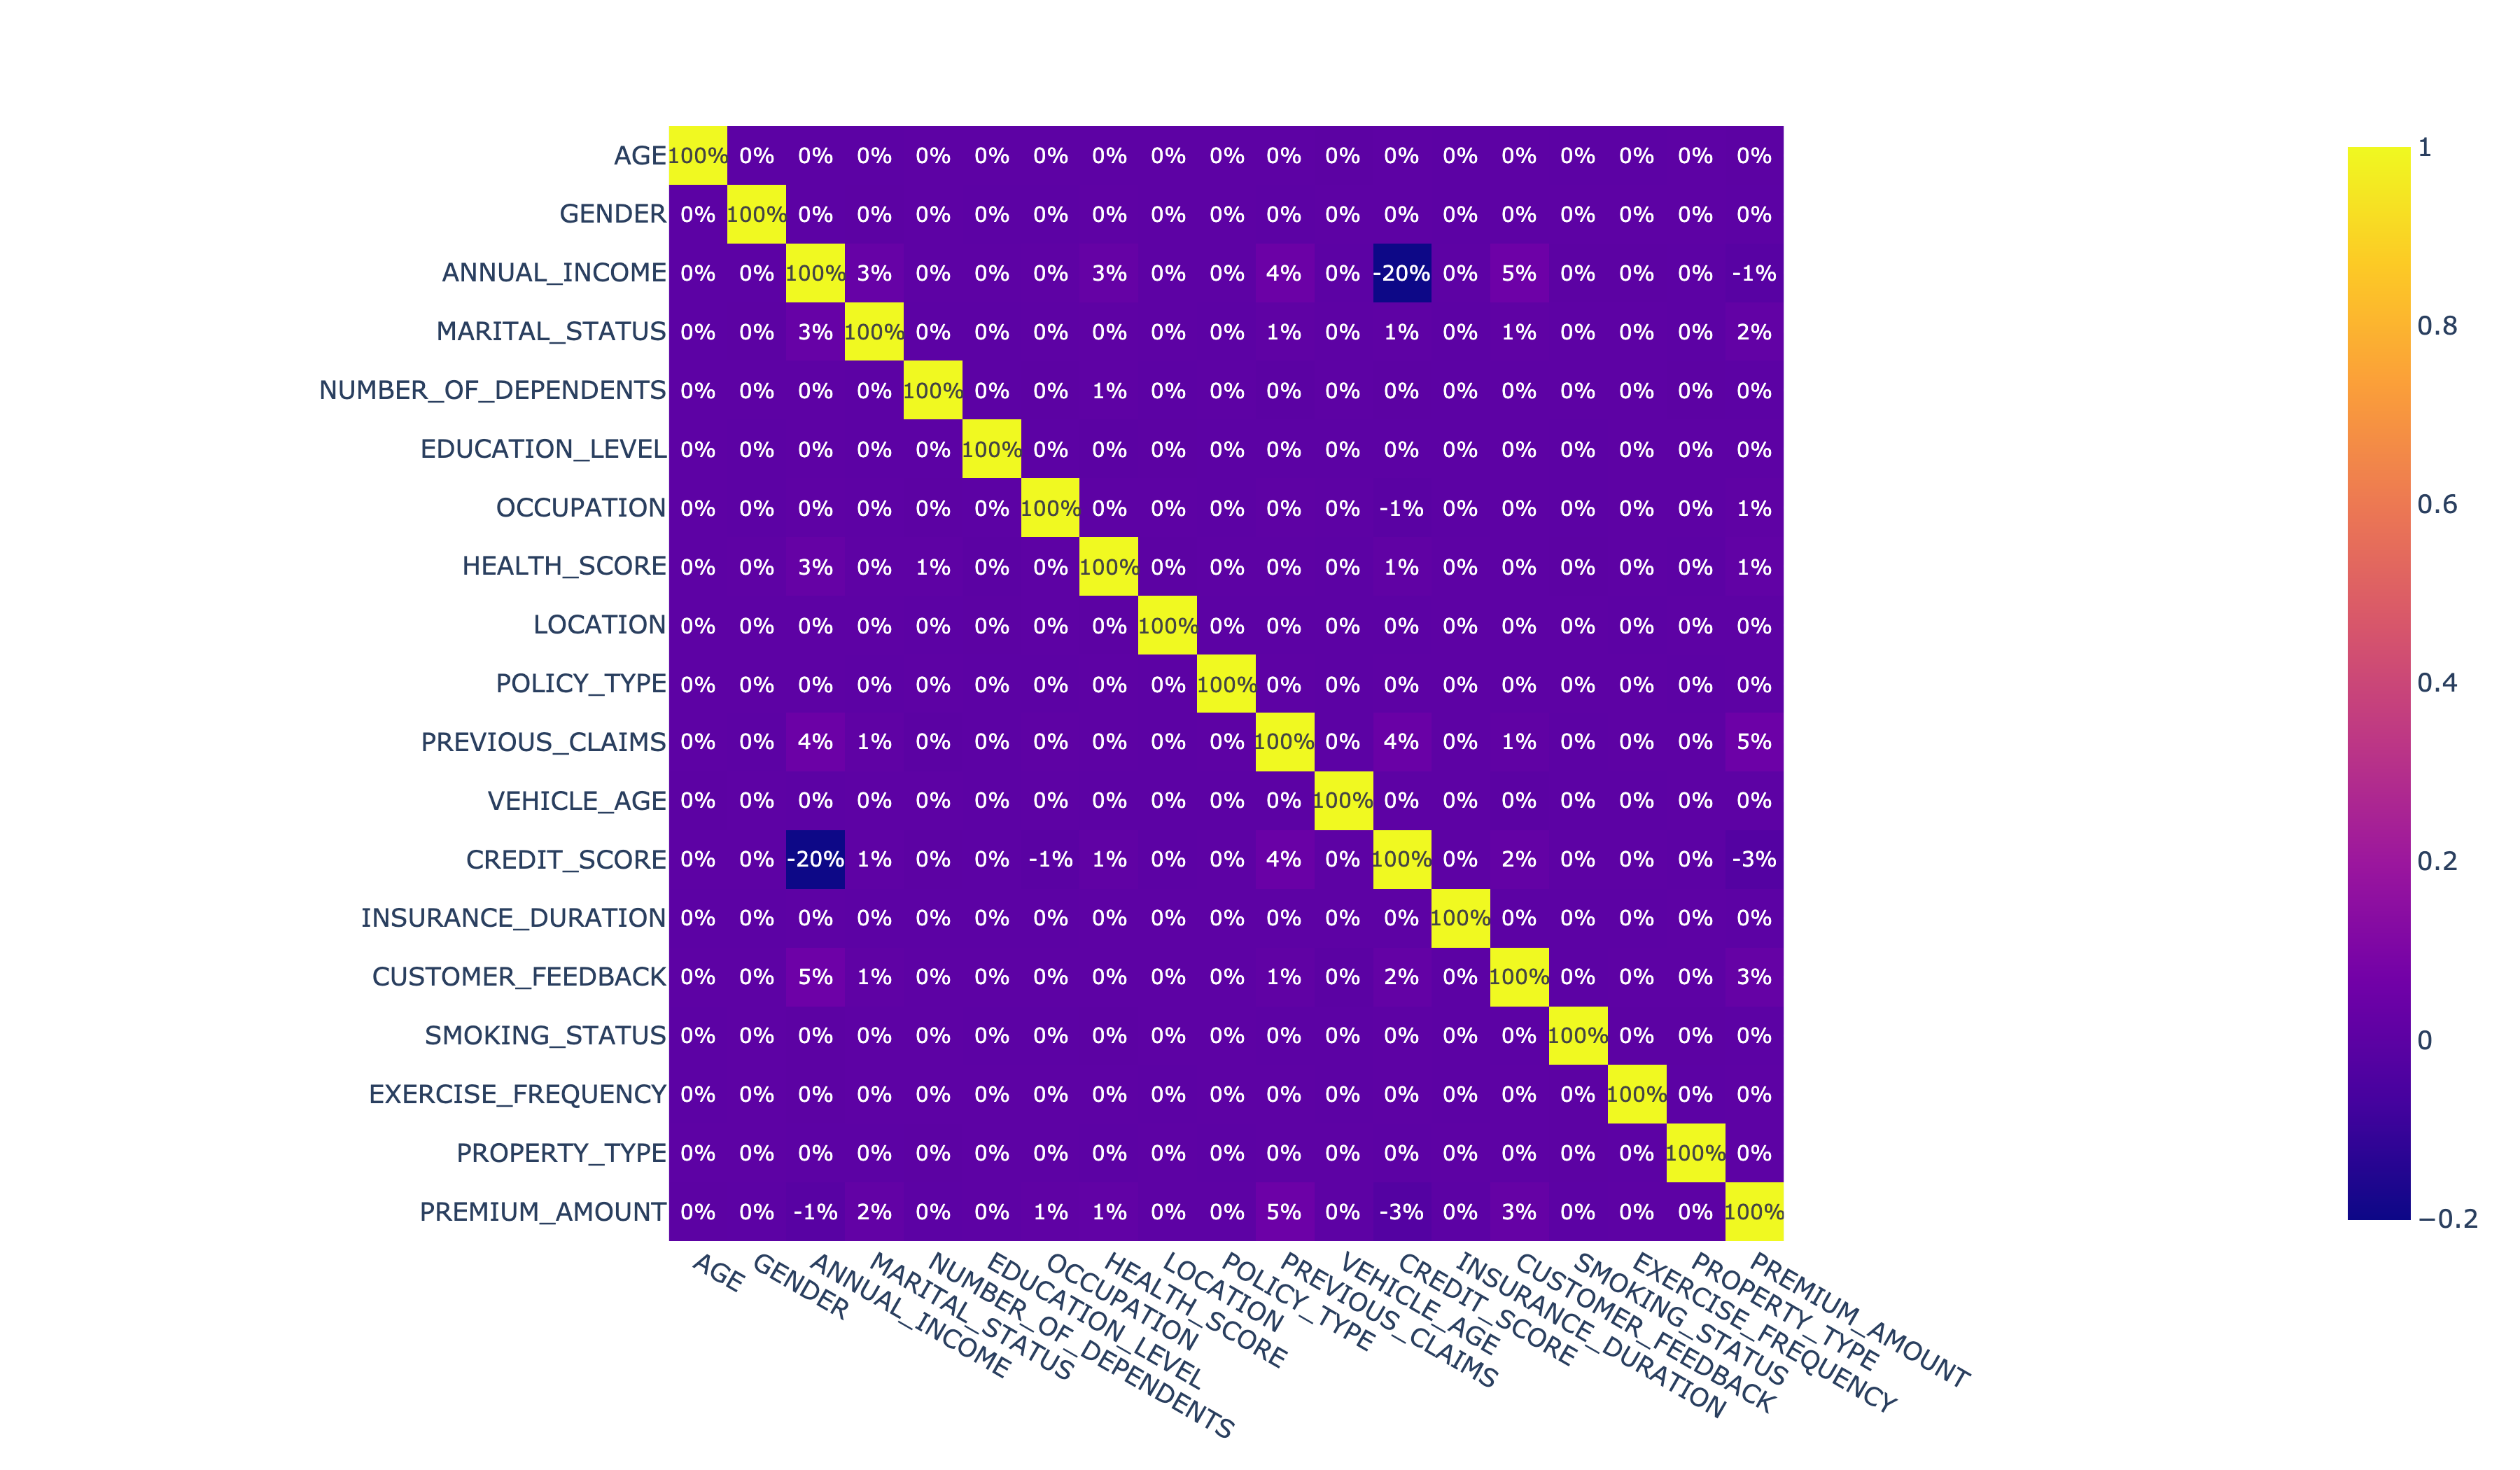

In [9]:
corr_table = data_enc.drop(columns=["ID", "POLICY_START_DATE"]).corr()

fig_corr = px.imshow(corr_table, text_auto=".0%")
fig_corr = fig_corr.update_xaxes(nticks=20)
fig_corr = fig_corr.update_yaxes(nticks=30)

fig_corr.show(**vs)

# Анализ пропущенных значений

Доля пропущенных значений в датасете стабильна по месяцам. В следующих полях присутствуют пропущенные значения:

1. PREVIOUS_CLAIMS – 30% пропущенных значений. В этом поле также присутствуют нулевые значения, что может означать отсутствие предыдущих обращений. Можем заполнить пропуски нулями.
2. OCCUPATION – 30% пропущенных значений. Возможно, клиенты не указывают свою профессию. Таблица корреляции показывает, что это поле не связано с PREVIOUS_CLAIMS в плане пропущенных значений. Не можем заполнить пропуски модой, так как это приведет к смещению данных. Можем попробовать заполнить пропуски отдельной категорией.
3. CREDIT_SCORE – 11% пропущенных значений. Можем попробовать заполнить пропуски медианой или средним значением.
4. NUMBER_OF_DEPENDENTS – 9% пропущенных значений. Можем попробовать заполнить пропуски медианой или средним значением.
5. CUSTOMER_FEEDBACK – 6.4% пропущенных значений
6. HEALTH_SCORE – 6.1% пропущенных значений
7. ANNUAL_INCOME – 3.7% пропущенных значений
8. AGE – 1.5% пропущенных значений
9. MARITAL_STATUS – 1.5% пропущенных значений
10. VEHICLE_AGE – 6 пропусков, можем заполнить модой.
11. INSURANCE_DURATION – один пропуск, можем заполнить модой.


In [10]:
missing_values = data.isnull().agg(["sum", "mean"]).T
missing_values.columns = ["n_missing", "p_missing"]
missing_values = missing_values.sort_values("p_missing", ascending=False)

missing_values

,n_missing,p_missing
PREVIOUS_CLAIMS,364029.0,3.033575e-01
OCCUPATION,358075.0,2.983958e-01
CREDIT_SCORE,137882.0,1.149017e-01
NUMBER_OF_DEPENDENTS,109672.0,9.139333e-02
CUSTOMER_FEEDBACK,77824.0,6.485333e-02
HEALTH_SCORE,74076.0,6.173000e-02
ANNUAL_INCOME,44949.0,3.745750e-02
AGE,18705.0,1.558750e-02
MARITAL_STATUS,18529.0,1.544083e-02
VEHICLE_AGE,6.0,5.000000e-06


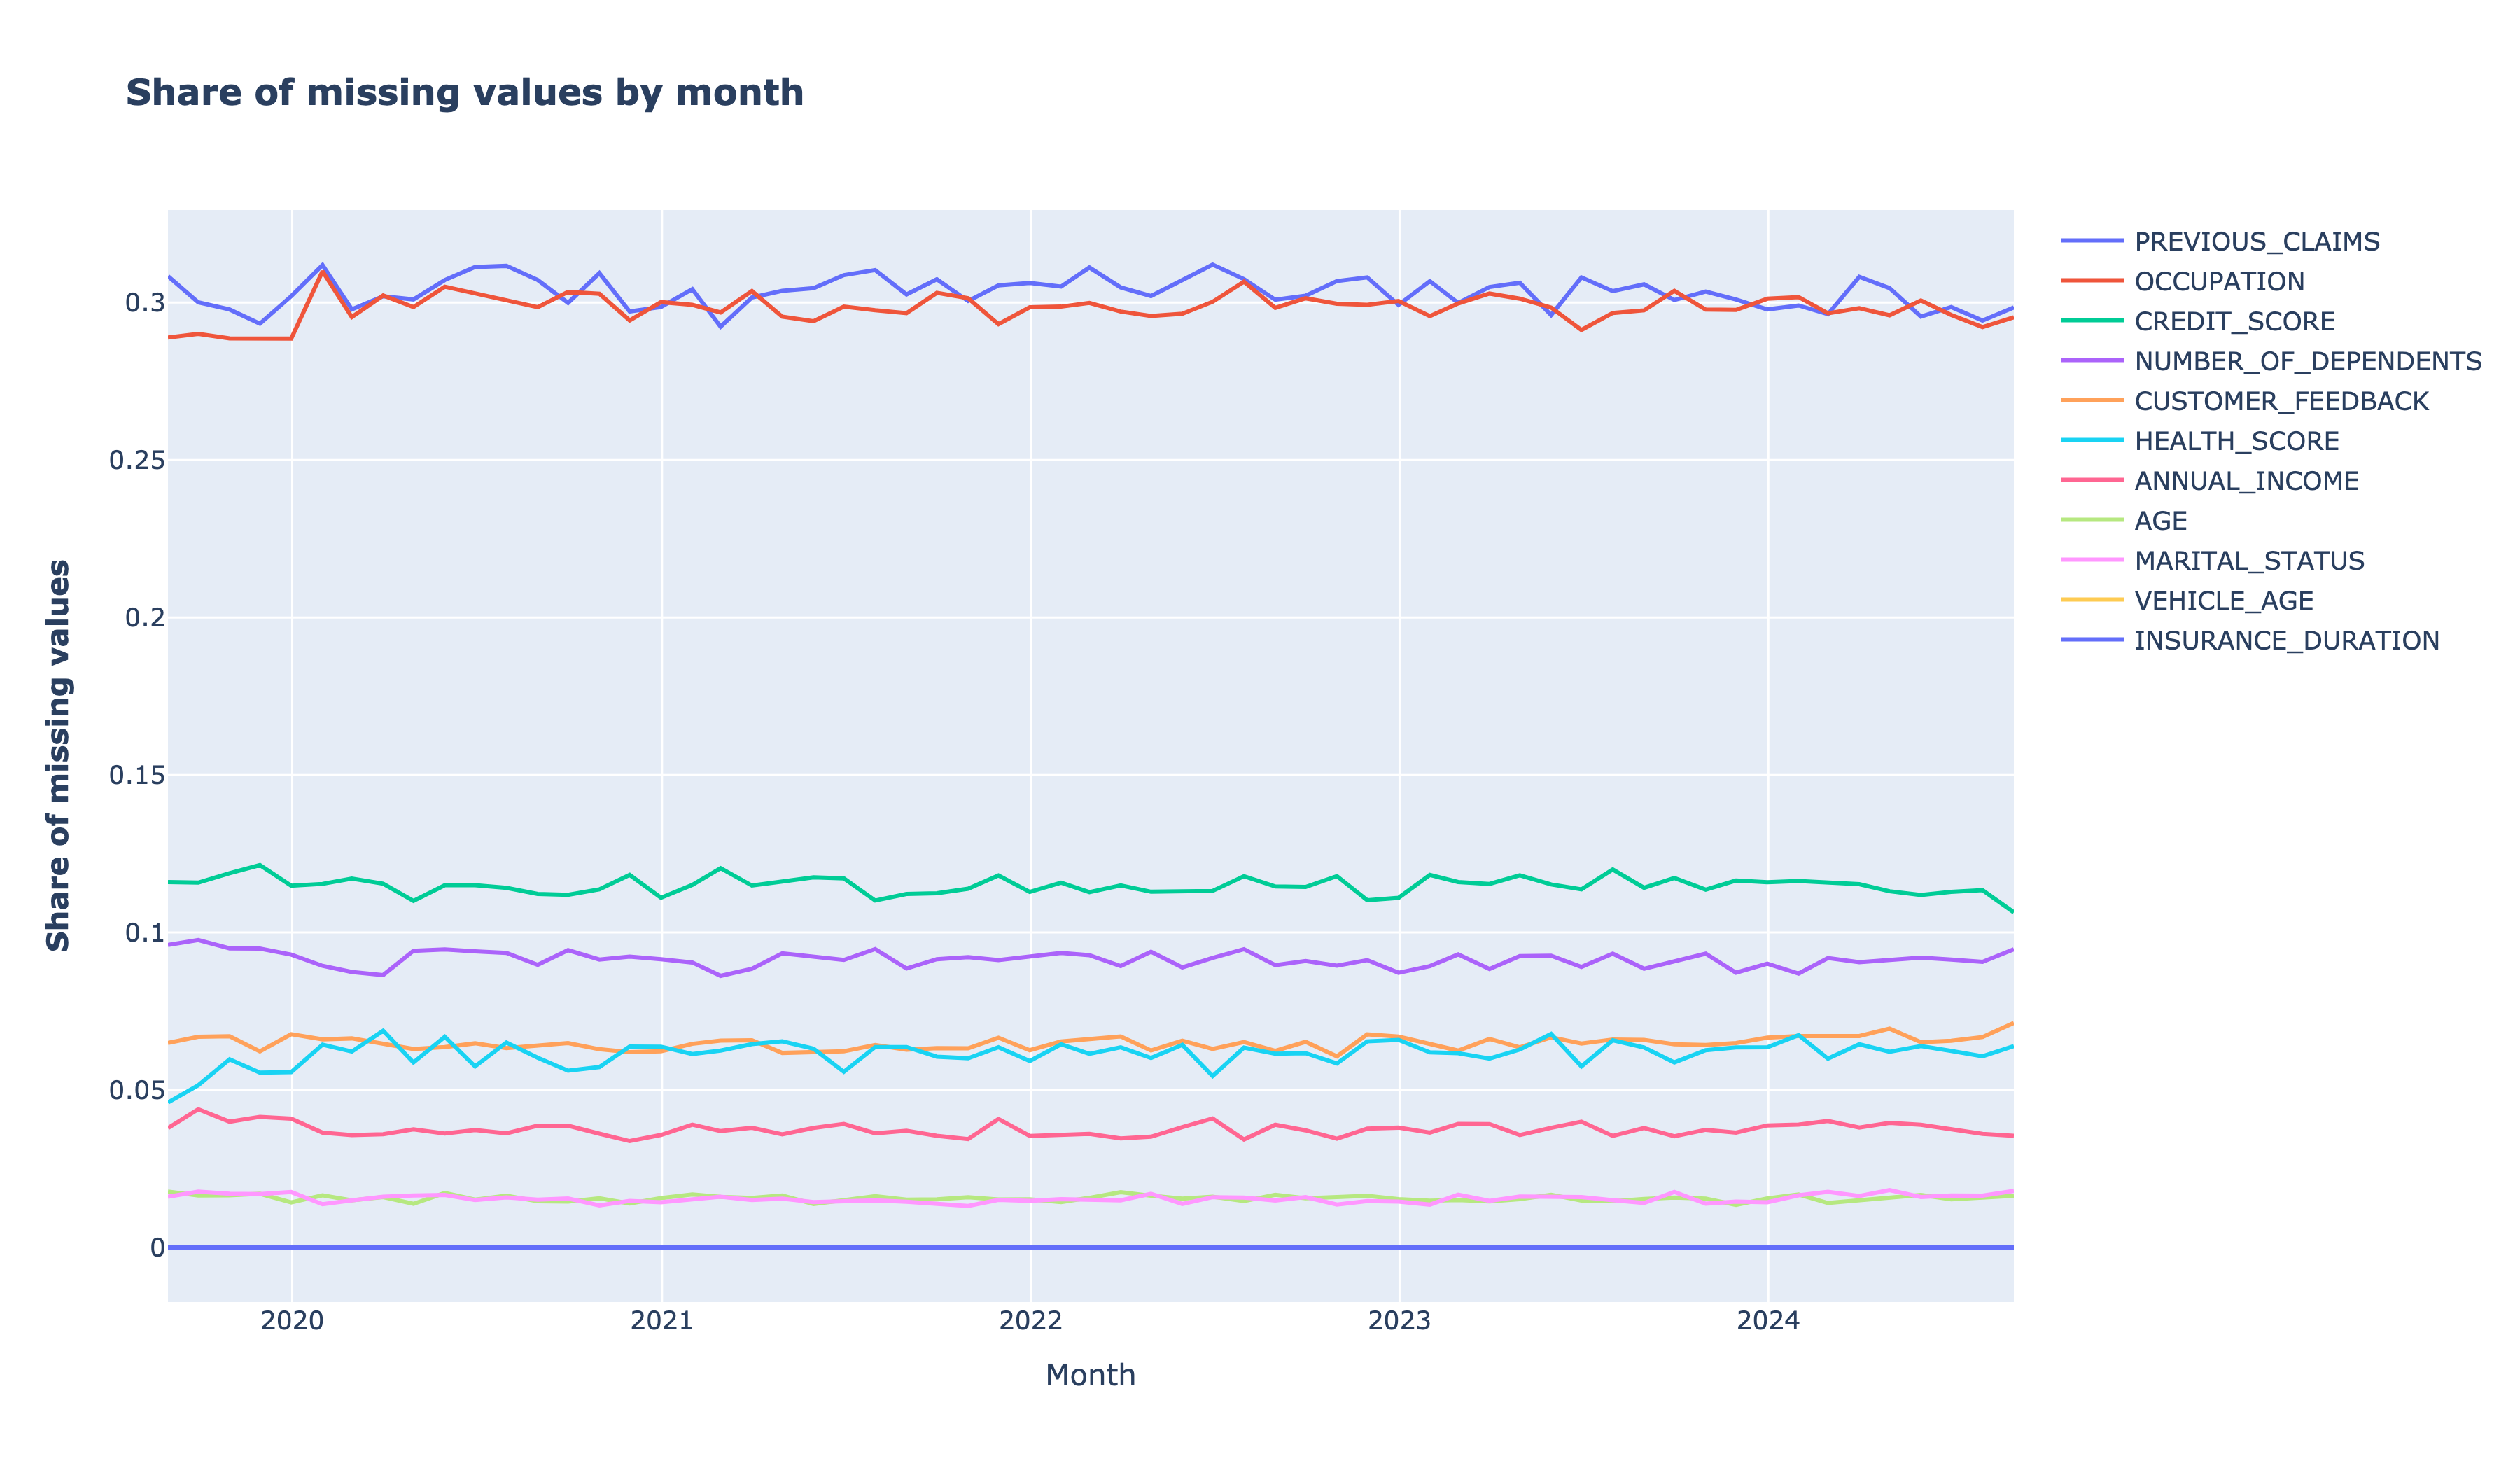

In [11]:
data['MONTH'] = pd.to_datetime(data["POLICY_START_DATE"]).dt.to_period('M')
data['MONTH'] = data['MONTH'].dt.strftime('%Y-%m-%d')

# group by month and calc null share for each feature
features = missing_values[missing_values['p_missing'] > 0].index
data_nulls = data[features].isnull().astype(int)
data_nulls['MONTH'] = data['MONTH']

missing_values_month = data_nulls.groupby('MONTH').mean()
missing_values_month = missing_values_month.reset_index()

fig_missing = make_subplots(rows=1, cols=1)
for feature in features:
    fig_missing.add_trace(
        go.Scatter(x=missing_values_month['MONTH'], y=missing_values_month[feature], mode='lines', name=feature),
    )

fig_missing.update_layout(
    title="<b>Share of missing values by month",
    xaxis_title="Month",
    yaxis_title="<b>Share of missing values",
    height=600,
    showlegend=True
)

fig_missing.show(**vs)

In [12]:
data_nulls.drop(columns='MONTH').corr()

,PREVIOUS_CLAIMS,OCCUPATION,CREDIT_SCORE,NUMBER_OF_DEPENDENTS,CUSTOMER_FEEDBACK,HEALTH_SCORE,ANNUAL_INCOME,AGE,MARITAL_STATUS,VEHICLE_AGE,INSURANCE_DURATION
PREVIOUS_CLAIMS,1.000000,0.000968,-0.004073,-0.004616,-0.005546,0.004538,-0.006173,0.001049,-0.004615,-0.000665,-0.000602
OCCUPATION,0.000968,1.000000,-0.001904,-0.001553,-0.000491,-0.003852,-0.001560,0.002463,-0.000384,-0.000644,-0.000595
CREDIT_SCORE,-0.004073,-0.001904,1.000000,-0.000422,0.006334,0.010136,-0.024685,-0.000005,0.003115,-0.000806,-0.000329
NUMBER_OF_DEPENDENTS,-0.004616,-0.001553,-0.000422,1.000000,0.004737,-0.006021,-0.001524,0.000758,0.004188,-0.000709,-0.000290
CUSTOMER_FEEDBACK,-0.005546,-0.000491,0.006334,0.004737,1.000000,0.001152,0.018033,0.002811,0.007364,-0.000589,-0.000240
HEALTH_SCORE,0.004538,-0.003852,0.010136,-0.006021,0.001152,1.000000,-0.007052,-0.001360,-0.006678,-0.000574,-0.000234
ANNUAL_INCOME,-0.006173,-0.001560,-0.024685,-0.001524,0.018033,-0.007052,1.000000,0.001394,0.009324,0.001522,-0.000180
AGE,0.001049,0.002463,-0.000005,0.000758,0.002811,-0.001360,0.001394,1.000000,0.000501,-0.000281,-0.000115
MARITAL_STATUS,-0.004615,-0.000384,0.003115,0.004188,0.007364,-0.006678,0.009324,0.000501,1.000000,-0.000280,-0.000114
VEHICLE_AGE,-0.000665,-0.000644,-0.000806,-0.000709,-0.000589,-0.000574,0.001522,-0.000281,-0.000280,1.000000,-0.000002


# Определение важности признаков (корреляции с таргетом)

На основе корреляции с таргетом можно сделать следующие выводы (график выше):

1. Все переменные имеют около-нулевую корреляцию с таргетом


In [13]:
charts_x_names = [
    (fig_distribution, 'NUMERICAL_FEATURES_DISTRIBUTION'),
    (fig_bars, 'CATEGORICAL_FEATURES_DISTRIBUTION'),
    (fig_corr, 'MUTUAL_CORRELATION_TABLE'),
    (fig_missing, 'MISSING_VALUES_BY_MONTH'),
]

for chart, name in charts_x_names:
    save_chart(chart, name, FIGURES_DIR / 'eda' / 'features_analysis', vs_box)